# Fire-product comparison — run & inspect

This notebook drives `peatfire.fire_products_comparison`

Key invariants:
- **Analysis CRS is always EPSG:5070** (equal-area) for area and grid comparison; the AOI's CRS is only a clip mask.
- The **common grid** (default 500 m, `how="max"` = "any sub-cell burn lights the cell") removes resolution as a confound.
- **Annual mode** ORs a product's monthly files into one yearly mask; **monthly mode** keeps each month separate and drops annual-only products.

## 0. Setup & area of interest (AOI)

In [1]:
%load_ext autoreload
%autoreload 2

import geopandas as gpd
import matplotlib.pyplot as plt

from peatfire import data_path
from peatfire.preproc import clip_raster_to_mask, clip_vector_to_mask
from peatfire.fire_products_comparison import (
    FIRE_PRODUCTS, list_products, get_spec, load_standardized,
    build_common_grid, to_common_grid, burned_area_km2,
    annual_burned_area_series, stack_on_common_grid, agreement_matrix,
    period_totals_series, product_pair_scatter, total_least_squares, rmse,
    compare_fire_products,
    set_fire_style, plot_annual_series, plot_agreement_heatmap,
    plot_overlay_map, plot_product_scatter, plot_temporal_heatmap,
    plot_consensus_map, plot_raster_map
)

import re
from peatfire.fire_products_comparison.plotting import OKABE_ITO

import rioxarray

set_fire_style()

# AOI: swap this path for NC peatlands / non-peatlands later -- nothing else changes.
aoi_nc = gpd.read_file(data_path("processed", "boundaries", "nc_boundary.gpkg"))
aoi_nc_peat = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_aoi.gpkg"))
aoi_nc_peat_80_histosol = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_80_histosol_aoi.gpkg"))
histosol = rioxarray.open_rasterio(data_path("processed", "peat_extent", "conus_histosol_major_percentage_nc.tif"), masked=True)
factor = 10
coarse_histosol = histosol.squeeze().coarsen(x=factor, y=factor, boundary='trim').mean() # build a coarser histosol map for plotting - DO NOT USE THIS FOR ANALYSES

peat_restoration = gpd.read_file(
    data_path(
        'processed', 'peat_restoration',
        'NC_Pocosin_Restoration_Sites_2026',
        'NC_Pocosin_Restoration_Sites_2026.shp'
    )
)

peat_restoration_controls = gpd.read_file(
    data_path(
        'processed', 'peat_restoration',
        'matched_controls', 'matched_controls.gpkg'
    )
)

completed_peat_restoration = peat_restoration[peat_restoration['Status_202'] == 'Completed']

# set which aoi you want to run fire analyses for
aoi_mapping = {
    'nc_peat_80_histosol': aoi_nc_peat_80_histosol,
    'aoi_nc': aoi_nc,
    'aoi_nc_peat': aoi_nc_peat,
    'peat_restoration': peat_restoration,
    'completed_peat_restoration': completed_peat_restoration,
    'completed_peat_restoration_controls': peat_restoration_controls
}

aoi_name = "completed_peat_restoration"
aoi = aoi_mapping[aoi_name]

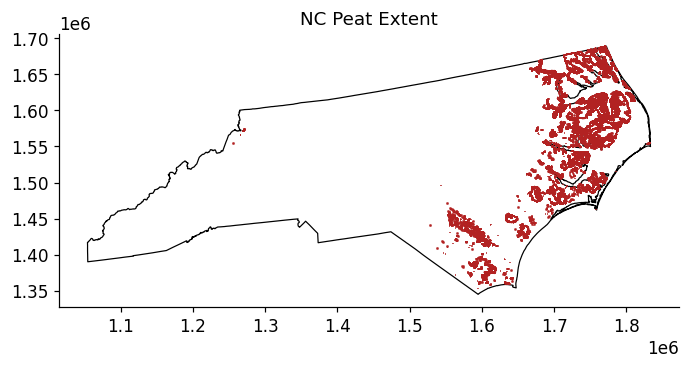

In [ ]:
# reproject vectors to match the raster so the layers align
plot_crs = coarse_histosol.rio.crs
aoi_nc = aoi_nc.to_crs(plot_crs)
aoi_nc_peat_80_histosol = aoi_nc_peat_80_histosol.to_crs(plot_crs)

fig, ax = plt.subplots()

# boundaries on top, no fill so the raster shows thru
aoi_nc.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)
aoi_nc_peat_80_histosol.plot(ax=ax, facecolor='none', edgecolor='firebrick', linewidth=1, alpha=1)
# ax.set_title('NC Peat Extent and Histosol %')
ax.set_title('NC Peat Extent')

plt.show()

## 1. What products are registered, and which have data on disk?

The registry is the single source of truth. `directory` resolves each product's folder via `data_path`.

In [3]:
import pandas as pd
rows = []
for name in list_products():
    s = get_spec(name)
    n_files = len(sorted(s.directory.glob(s.glob))) if s.directory.exists() else 0
    rows.append({"product": name, "family": s.family, "res_m": s.native_res_m,
                 "temporal": s.temporal, "monthly": s.month_parser is not None,
                 "dir_exists": s.directory.exists(), "n_files": n_files,
                 "directory": str(s.directory)})
pd.DataFrame(rows).set_index("product")

,family,res_m,temporal,monthly,dir_exists,n_files,directory
product,,,,,,,
MCD64A1,burned_area,500.0,monthly,True,True,305,/Users/jinjiang-macair/Library/CloudStorage/On...
GABAM,burned_area,30.0,annual,False,True,29,/Users/jinjiang-macair/Library/CloudStorage/On...
FireCCI51,burned_area,250.0,monthly,True,True,240,/Users/jinjiang-macair/Library/CloudStorage/On...
FireCCIS311,burned_area,300.0,monthly,True,True,72,/Users/jinjiang-macair/Library/CloudStorage/On...
VIIRS,occurrence,375.0,events,False,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
SE_FireMap,severity,30.0,annual,False,True,23,/Users/jinjiang-macair/Library/CloudStorage/On...
MOSEV,severity,500.0,monthly,True,True,236,/Users/jinjiang-macair/Library/CloudStorage/On...
MTBS,severity,30.0,annual,False,True,40,/Users/jinjiang-macair/Library/CloudStorage/On...


## 2. Load ONE product for ONE year, and inspect every sub-step

We trace MCD64A1 / 2017. First the raw clip (note it keeps a singleton `band` dim), then the
standardized annual mask the toolkit actually uses (band squeezed, months OR'd).

In [4]:
product, year = "MOSEV", 2017
spec = get_spec(product)

# (a) the monthly files the loader will group for this year
files = sorted(spec.directory.glob(spec.glob))
files_2017 = [f for f in files if spec.year_parser(f) == year]
print(f"{product}: {len(files_2017)} monthly files for {year}")
for f in files_2017[:3]:
    print("   ", f.name, "-> month", spec.month_parser(f))

# (b) raw clip of a single month (in memory). Still has a band dimension.
one = clip_raster_to_mask(files_2017[0], aoi)
print("\nsingle clipped month -> dims:", dict(one.sizes), "| CRS:", one.rio.crs)

MOSEV: 12 monthly files for 2017
    MOSEV_A2017001_nc.tif -> month 1
    MOSEV_A2017032_nc.tif -> month 2
    MOSEV_A2017060_nc.tif -> month 3

single clipped month -> dims: {'band': 7, 'y': 448, 'x': 631} | CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


annual mask name : MOSEV
dims             : {'y': 448, 'x': 631}
CRS              : PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]] (native sinusoidal)
burned pixels    : 0


/Users/jinjiang-macair/anaconda3/envs/peat_fire_stanback/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


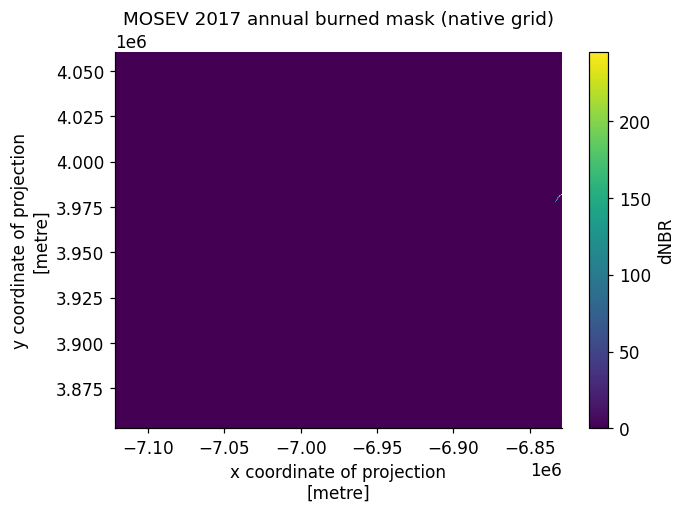

In [5]:
# (c) the standardized ANNUAL mask (band squeezed, 12 months OR'd, True=burned)
mask = load_standardized(product, year, aoi)
print("annual mask name :", mask.name)
print("dims             :", dict(mask.sizes))
print("CRS              :", mask.rio.crs, "(native sinusoidal)")
print("burned pixels    :", int((mask.values == True).sum()))
mask.astype("uint8").plot(); plt.title(f"{product} {year} annual burned mask (native grid)"); plt.show()

## 3. The common grid (the resolution-confound fix)

`build_common_grid` makes an empty EPSG:5070 reference grid over the AOI; `to_common_grid` warps any
product onto it with `how="max"`. Every product is matched to THIS grid, so none is privileged.

common grid CRS  : EPSG:5070
common grid shape: {'y': 460, 'x': 336}
pixel size (m)   : (500.0, -500.0)

mask on common grid -> dims: {'y': 460, 'x': 336} | CRS: EPSG:5070


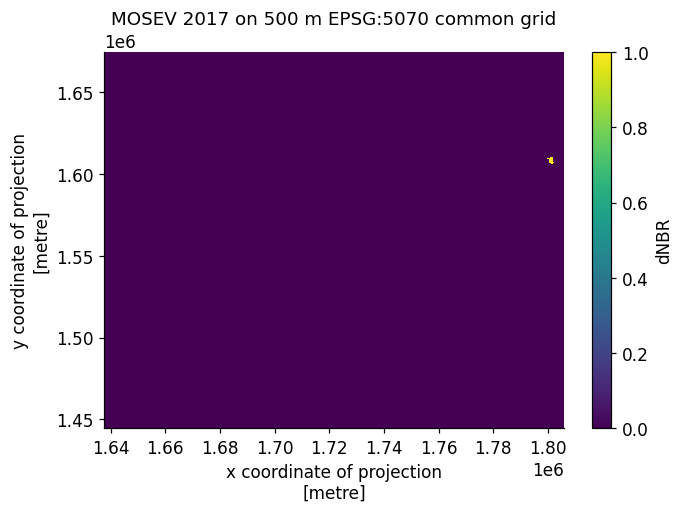

In [6]:
grid = build_common_grid(aoi, res_m=500.0)
print("common grid CRS  :", grid.rio.crs)
print("common grid shape:", dict(grid.sizes))
print("pixel size (m)   :", grid.rio.resolution())

mask_cg = to_common_grid(mask.astype("float32"), grid, how="max") > 0
print("\nmask on common grid -> dims:", dict(mask_cg.sizes), "| CRS:", mask_cg.rio.crs)
mask_cg.astype("uint8").plot(); plt.title(f"{product} {year} on 500 m EPSG:5070 common grid"); plt.show()

## 4. Annual burned-area series — native vs common-grid (Humber Figure 3)

`mode="native"` uses each product's own pixel area; `mode="common_grid"` puts everyone on the shared
500 m grid first. Comparing the two shows how much of any product difference is just resolution.

### 4b. Fire around treatment (event-time alignment)

Each restoration site was treated in a different calendar year (`End_Yr`). To ask
"what does fire look like around treatment?" across sites, we re-index every site's
series to **years since its own treatment** (`event_year = calendar_year - End_Yr`),
keep a ±5-year window, and pool sites by event-year. Burned area (km², from the
burned-area products) and VIIRS active-fire detections (counts) are pulled together
with `period_totals_series`, then plotted in two stacked panels sharing the
event-time axis (0 = treatment year).

Three views are produced:
1. **composite, absolute** — mean km² / detections across sites per event-year;
2. **composite, area-normalised** (`normalize=True`) — % of site burned and
   detections/km², normalised *per site before averaging* so a large site can't
   dominate;
3. **per site** — the same figure for each `Proj_Name` individually (expect many
   flat/empty panels; a single small pocosin rarely has mapped fire).


In [11]:
# ── Event-time alignment: burned area + VIIRS around each site's treatment year ──
#
# Each restoration site was treated in a DIFFERENT calendar year (`End_Yr`), so
# a raw calendar-year x-axis is the wrong frame: it smears the treatments across
# time and never lines up "the year of treatment" for sites treated in different
# years. The fix is the standard *event-study* re-indexing: for every site,
# replace the calendar year with `event_year = calendar_year - End_Yr`, so 0 is
# the treatment year, negative is pre-treatment, positive is post. Then a given
# event-year column pools sites treated in different calendar years.
#
# Two things to get right that the scratch version missed:
#   1. A "site" is one `Proj_Name`, which can be SEVERAL polygon rows (e.g.
#      "Clayton Blocks" is two) -> group by Proj_Name and pass the whole group's
#      geometry as the AOI (don't iterate rows, and don't pass the full `aoi`).
#   2. We want burned area (km^2) AND VIIRS active-fire detections (counts) on the
#      same footing -> `period_totals_series` returns both in one frame (km^2 for
#      burned-area products, detection count for the occurrence product), whereas
#      `annual_burned_area_series` silently drops VIIRS.

WINDOW = 5                                              # years kept on each side of treatment
products_ba = ["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311"]
value_products = products_ba + ["VIIRS"]               # burned area (km^2) + VIIRS detections (count)

SITE_COL, START_COL = "Proj_Name", "End_Yr"


def event_time_series(sites_gdf, products, window=WINDOW):
    """Long, tidy per-site time series aligned to each site's treatment year.

    For every treatment site (one `Proj_Name`, possibly several polygons), clip to
    that site's geometry and pull per-year totals over
    ``[End_Yr - window, End_Yr + window]`` with ``period_totals_series`` --
    burned area (km^2) for the burned-area products and detection count for VIIRS.
    Add ``event_year = calendar_year - End_Yr`` and a per-site-area-normalised
    ``value_per_km2`` (burned *fraction* for area products, detections/km^2 for
    VIIRS -- so sites of very different size are comparable), then stack all sites
    into one long DataFrame. Long form keeps site/product/time as data, not column
    names, so aggregating or faceting later is a one-liner.
    """
    frames = []
    for site_name, site_gdf in sites_gdf.groupby(SITE_COL):
        start = site_gdf[START_COL].dropna()
        if start.empty:                                # e.g. baseline-monitoring sites with no treatment
            print(f"skip {site_name!r}: no {START_COL}")
            continue
        start = int(start.iloc[0])
        years = range(start - window, start + window + 1)
        site_km2 = float(site_gdf.to_crs("EPSG:5070").area.sum()) / 1e6

        totals = period_totals_series(products, years, site_gdf, temporal_unit="year")
        # wide (year x product) -> long, so every (year, product) is one row
        long = (
            totals.reset_index()
            .melt(id_vars="year", var_name="product", value_name="value")
            .rename(columns={"year": "calendar_year"})
        )
        long["site"] = site_name
        long["End_Yr"] = start
        long["event_year"] = long["calendar_year"] - start
        long["site_km2"] = site_km2
        long["value_per_km2"] = long["value"] / site_km2   # fraction (BA) or det/km^2 (VIIRS)
        frames.append(long)

    return pd.concat(frames, ignore_index=True)


if 'restoration' in aoi_name:
    et = event_time_series(aoi, value_products)
    print(f"{et['site'].nunique()} sites, event_year in "
        f"[{et['event_year'].min()}, {et['event_year'].max()}]")
    display(et.head())


7 sites, event_year in [-5, 5]


,calendar_year,product,value,site,End_Yr,event_year,site_km2,value_per_km2
0,2014,MCD64A1,0.0,ARNWR Restoration East,2019,-5,47.096396,0.000000
1,2015,MCD64A1,0.0,ARNWR Restoration East,2019,-4,47.096396,0.000000
2,2016,MCD64A1,0.0,ARNWR Restoration East,2019,-3,47.096396,0.000000
3,2017,MCD64A1,7.5,ARNWR Restoration East,2019,-2,47.096396,0.159248
4,2018,MCD64A1,0.0,ARNWR Restoration East,2019,-1,47.096396,0.000000


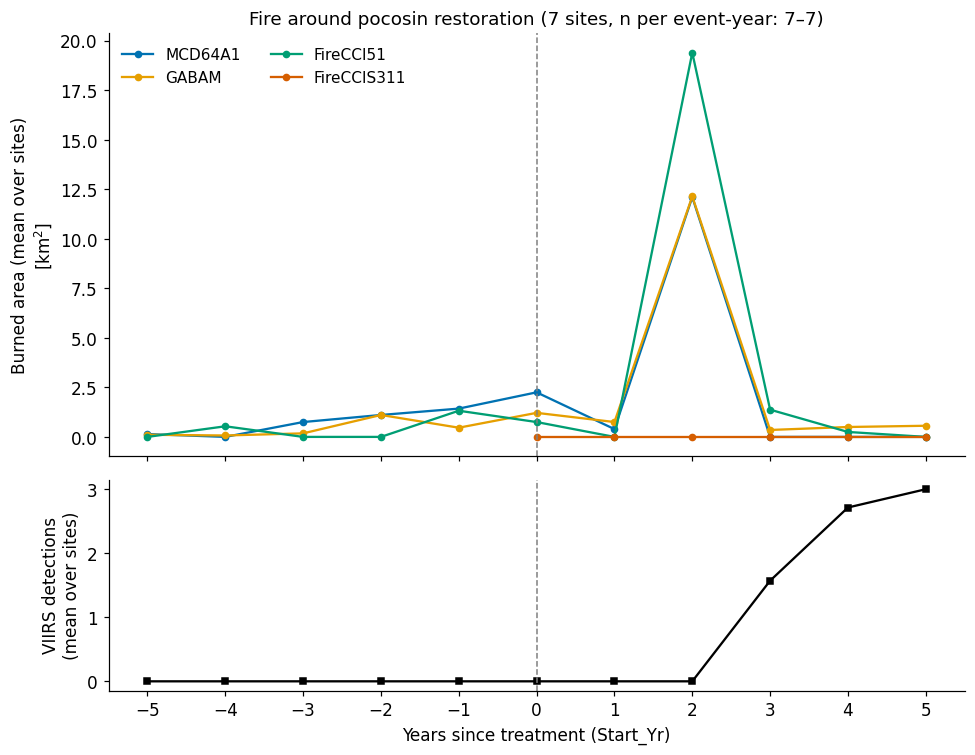

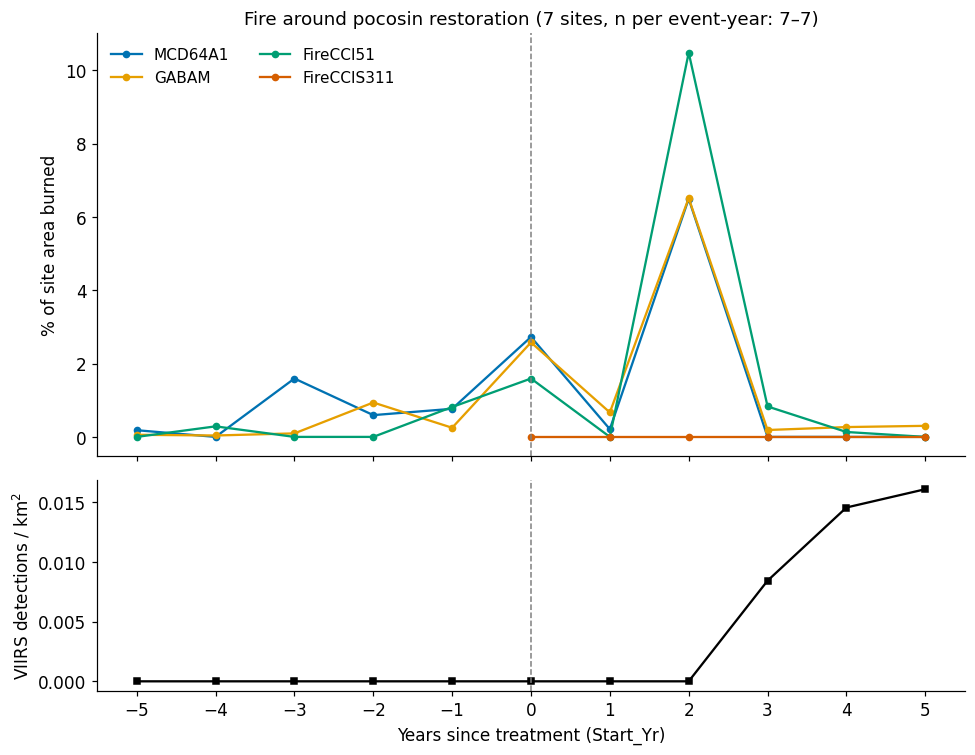

In [ ]:
# ── Plot the event-time composite: mean across sites at each event-year ──
#
# We aggregate over sites with the MEAN at each event-year (mean over the sites
# that have data there, so partial VIIRS coverage or a short product record just
# thins the average instead of dropping the column). Burned-area products (km^2)
# and VIIRS detections (counts) live in different units, so they go in two stacked
# panels sharing the event-time x-axis rather than being forced onto one y-axis.
# The dashed line at 0 is the treatment year; left of it is pre-treatment.
#
# `normalize=True` switches to the per-site-area-normalised column: burned *area*
# becomes "% of the site that burned" and VIIRS becomes "detections / km^2". Do
# the normalisation PER SITE before averaging (already baked into `value_per_km2`),
# so a big site can't dominate the composite just by being big.


def _slug(s):
    return re.sub(r"[^0-9A-Za-z]+", "_", str(s)).strip("_")


def plot_event_time(et, ba_products, occurrence="VIIRS", agg="mean",
                    normalize=False, title=None):
    set_fire_style()
    col = "value_per_km2" if normalize else "value"
    ba_scale = 100.0 if normalize else 1.0                 # burned fraction -> % of site area
    wide = et.groupby(["event_year", "product"])[col].agg(agg).unstack("product")
    n_sites = et.groupby("event_year")["site"].nunique()

    fig, (ax_ba, ax_vi) = plt.subplots(
        2, 1, figsize=(9, 7), sharex=True, height_ratios=[2, 1]
    )
    colours = dict(zip(ba_products, OKABE_ITO))
    for p in ba_products:
        if p in wide:
            ax_ba.plot(wide.index, wide[p] * ba_scale, marker="o", ms=4,
                       color=colours[p], label=p)
    ax_ba.set_ylabel("% of site area burned" if normalize
                     else f"Burned area ({agg} over sites)\n[km$^2$]")
    ax_ba.legend(title=None, ncol=2)

    if occurrence in wide:
        ax_vi.plot(wide.index, wide[occurrence], marker="s", ms=4, color="#000000")
    ax_vi.set_ylabel("VIIRS detections / km$^2$" if normalize
                     else f"VIIRS detections\n({agg} over sites)")
    ax_vi.set_xlabel("Years since treatment (End_Yr)")

    for ax in (ax_ba, ax_vi):
        ax.axvline(0, ls="--", color="grey", lw=1)          # treatment year
        ax.set_xticks(range(int(wide.index.min()), int(wide.index.max()) + 1))
    ax_ba.set_title(title or (
        f"Fire around pocosin restoration ({et['site'].nunique()} sites, "
        f"n per event-year: {n_sites.min()}–{n_sites.max()})"))
    return fig


# composite across all sites, absolute and area-normalised
if 'restoration' in aoi_name:
    for norm, tag in [(False, "absolute"), (True, "per_km2")]:
        fig = plot_event_time(et, products_ba, normalize=norm)
        fig.savefig(
            f"../outputs/figures/fire/event_time_{tag}_burned_area_and_viirs_{aoi_name}.png",
            dpi=150, bbox_inches="tight",
        )
        plt.show()


In [9]:
# ── Same plot, one figure per treatment site (+ a locator map on NC) ──
#
# `plot_event_time` already collapses over sites with the mean, so a single-site
# subset is just that site (mean over one = itself) -- no special-casing needed,
# we reuse the exact same function. As you expected, most individual pocosin
# sites see little or no mapped fire in an 11-year window, so many panels will be
# flat/empty; that's the honest signal, not a bug. Flip SITE_NORMALIZE for the
# area-normalised version (% of site burned, detections/km^2).
#
# For each site we also draw a small locator map -- the site (firebrick) on the
# NC outline, same style as the whole-AOI-over-NC plot up top -- so each fire
# figure is easy to place. A single pocosin can be a sub-pixel dot at state
# scale, so we add a star at its centroid to make it findable. Both figures are
# titled with the site name so they pair up.
SITE_NORMALIZE = True


def plot_site_on_nc(site_gdf, nc, title=None, ax=None):
    """Locator map: one restoration site (firebrick) on the NC outline.

    Mirrors the whole-AOI-over-NC plot -- NC boundary, no fill, site drawn on top
    -- but for a single `Proj_Name`. Reprojects the site into the NC layer's CRS
    so the two align, and marks the site centroid with a star so even a tiny site
    is visible at state scale.
    """
    set_fire_style()
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure
    site = site_gdf.to_crs(nc.crs)
    nc.boundary.plot(ax=ax, color="black", linewidth=0.8)
    site.plot(ax=ax, facecolor="firebrick", edgecolor="firebrick", linewidth=1)
    # centroid in an equal-area CRS (avoids a geographic-centroid warning), then
    # back to the map CRS -- a star so a sub-pixel site is still findable.
    c = site_gdf.to_crs("EPSG:5070").geometry.union_all().centroid
    c = gpd.GeoSeries([c], crs="EPSG:5070").to_crs(nc.crs).iloc[0]
    ax.plot(c.x, c.y, marker="*", ms=14, color="firebrick",
            markeredgecolor="black", markeredgewidth=0.5)
    ax.set_aspect("equal")
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return fig

if 'restoration' in aoi_name:
    for site_name, site_et in et.groupby("site"):
        end = int(site_et["end_yr"].iloc[0])
        km2 = site_et["site_km2"].iloc[0]
        site_gdf = aoi[aoi[SITE_COL] == site_name]              # this site's polygon(s)

        # locator: where is this site in NC?
        loc = plot_site_on_nc(site_gdf, aoi_nc, title=site_name)
        loc.savefig(
            f"../outputs/figures/fire/locator_{_slug(site_name)}_{aoi_name}.png",
            dpi=150, bbox_inches="tight",
        )
        plt.show()

        # the event-time fire figure for the same site
        fig = plot_event_time(
            site_et, products_ba, normalize=SITE_NORMALIZE,
            title=f"{site_name} — End_Yr {end}, {km2:.1f} km$^2$",
        )
        tag = "per_km2" if SITE_NORMALIZE else "absolute"
        fig.savefig(
            f"../outputs/figures/fire/event_time_{tag}_{_slug(site_name)}_{aoi_name}.png",
            dpi=150, bbox_inches="tight",
        )
        plt.show()

KeyError: 'end_yr'

In [ ]:
products_ba = ["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311"]   # absent ones skip with a warning
# products_ba = ["FireCCI51"]   # absent ones skip with a warning

years = range(2001, 2022)

area_native = annual_burned_area_series(products_ba, years, aoi, mode="native")
area_cg     = annual_burned_area_series(products_ba, years, aoi, mode="common_grid")
display(area_native.head())
display(area_cg.head())

,MCD64A1,MCD64A1_pct_aoi,GABAM,GABAM_pct_aoi,FireCCI51,FireCCI51_pct_aoi,FireCCIS311,FireCCIS311_pct_aoi
year,,,,,,,,
2001,0.000000,NaN,0.0081,NaN,0.0,NaN,NaN,NaN
2002,0.000000,NaN,0.0000,NaN,0.0,NaN,NaN,NaN
2003,5.151808,NaN,0.0009,NaN,0.0,NaN,NaN,NaN
2004,0.643976,NaN,0.0027,NaN,0.0,NaN,NaN,NaN
2005,0.000000,NaN,0.0045,NaN,0.0,NaN,NaN,NaN


,MCD64A1,MCD64A1_pct_aoi,GABAM,GABAM_pct_aoi,FireCCI51,FireCCI51_pct_aoi,FireCCIS311,FireCCIS311_pct_aoi
year,,,,,,,,
2001,0.00,NaN,2.0,NaN,0.0,NaN,NaN,NaN
2002,0.00,NaN,0.0,NaN,0.0,NaN,NaN,NaN
2003,7.00,NaN,0.5,NaN,0.0,NaN,NaN,NaN
2004,1.25,NaN,1.5,NaN,0.0,NaN,NaN,NaN
2005,0.00,NaN,1.5,NaN,0.0,NaN,NaN,NaN


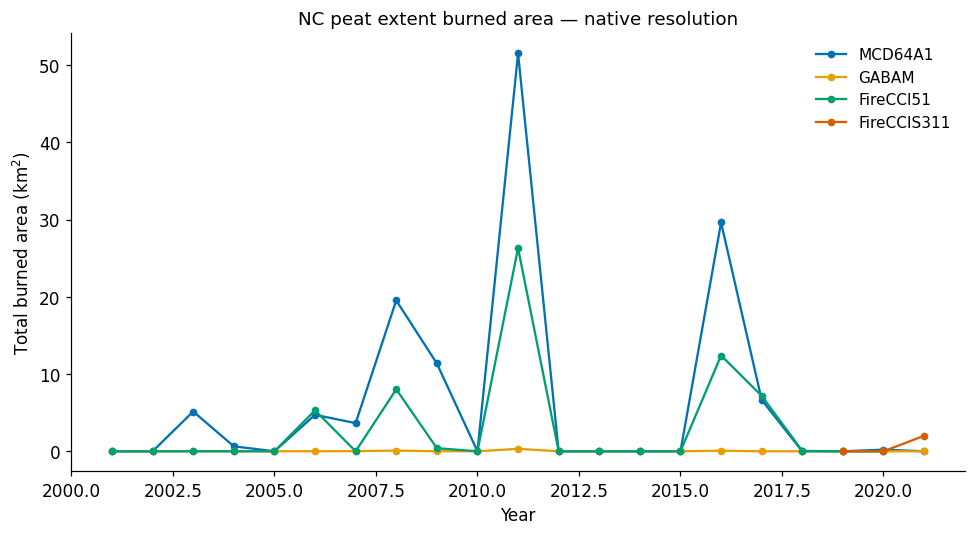

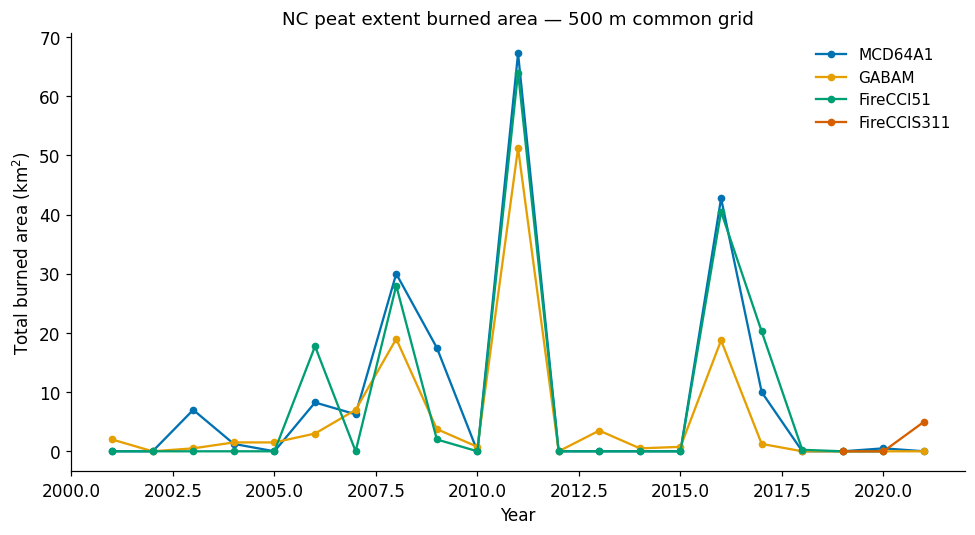

In [ ]:
native_res_annual_series = plot_annual_series(area_native, title="NC peat extent burned area — native resolution"); plt.show()
common_res_annual_series = plot_annual_series(area_cg,     title="NC peat extent burned area — 500 m common grid"); plt.show()

native_res_annual_series.savefig(f'../outputs/figures/fire/native_res_annual_series_{aoi_name}_extent_burned_area.png', dpi=150, bbox_inches='tight')
common_res_annual_series.savefig(f'../outputs/figures/fire/common_res_annual_series_{aoi_name}_extent_burned_area.png', dpi=150, bbox_inches='tight')


viirs counts - don't run this if not including viirs

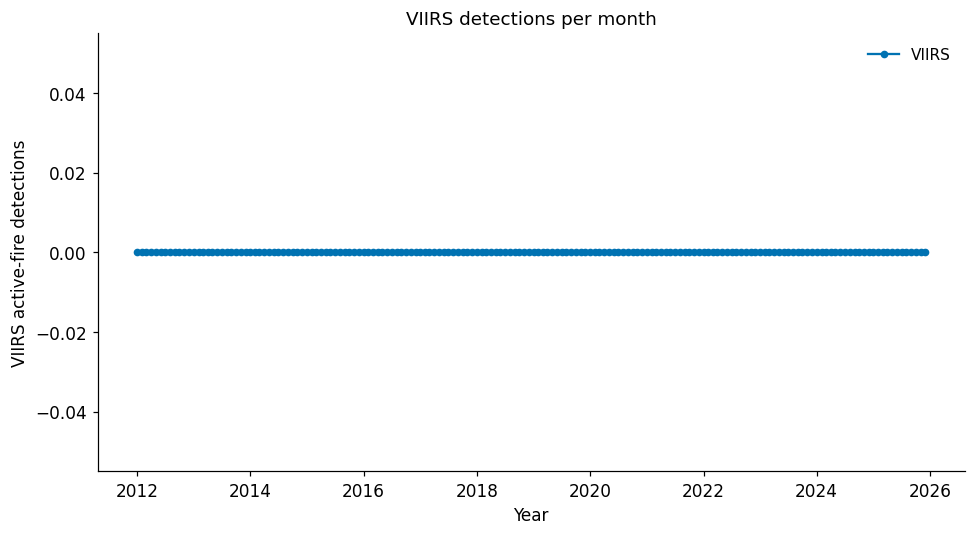

In [ ]:
counts_ts = period_totals_series(["VIIRS"], range(2012, 2026), aoi, temporal_unit="month")
counts_annual_series = plot_annual_series(counts_ts, ylabel="VIIRS active-fire detections", title="VIIRS detections per month")
counts_annual_series.savefig(f'../outputs/figures/fire/viirs_detections_per_month_in_{aoi_name}_extent.png', dpi=150, bbox_inches='tight')

## 5. Agreement matrices ("confusion-matrix" heatmaps)

VIIRS is included as the independent occurrence check. Binary spatial agreement (Jaccard, kappa) and
temporal correlation of annual totals answer different questions.

In [ ]:
# products_all = ["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"]
products_sev = ['SE_FireMap', 'MOSEV', 'MTBS']

jac = agreement_matrix(products_all, years, aoi, method="jaccard", pooling="cells")
kap = agreement_matrix(products_all, years, aoi, method="kappa",   pooling="cells")
cor = agreement_matrix(products_ba,  years, aoi, method="pearson", pooling="years")

if products_sev is not None:
    years = range(2000, 2021)
    spearman_cor = agreement_matrix(products_sev, years, aoi, method="spearman", pooling="cells")
    display(spearman_cor.round(2))
else:
    display(jac.round(2)); display(cor.round(2))

NameError: name 'products_all' is not defined

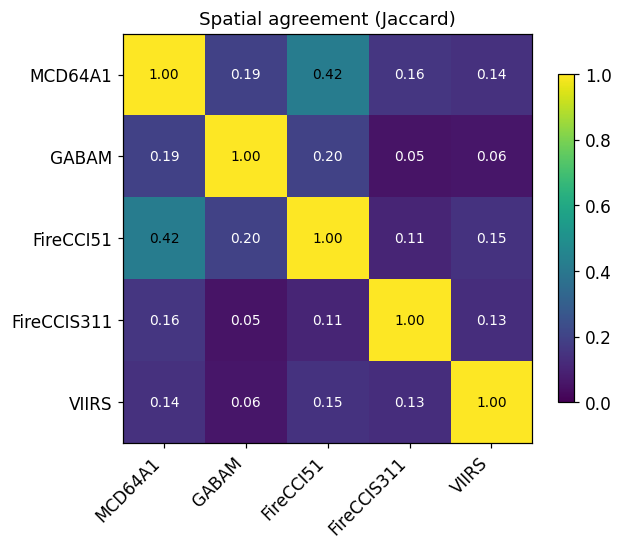

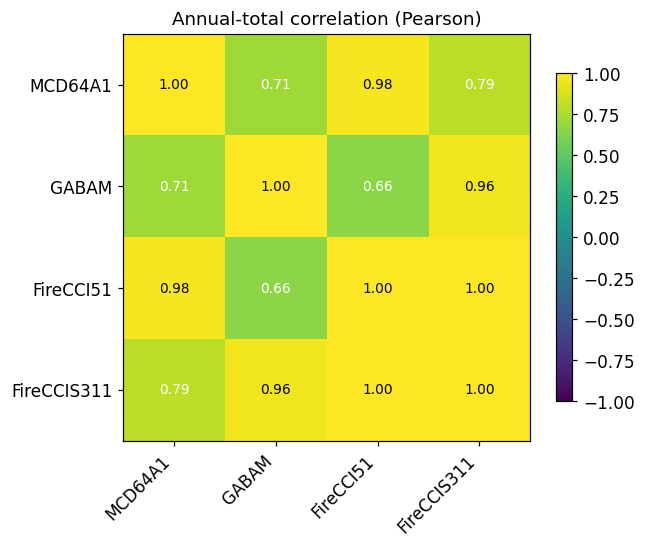

In [ ]:
if 'products_sev' in locals():
    spearman = plot_agreement_heatmap(spearman_cor, title="Annual-total correlation (Spearman)", vmin=-1, vmax=1); plt.show()
    spearman.savefig(f'../outputs/figures/fire/spearman_severity_{aoi_name}_extent.png', dpi=150, bbox_inches='tight')
    
else:
    jac = plot_agreement_heatmap(jac, title="Spatial agreement (Jaccard)", vmin=0, vmax=1); plt.show()
    jac.savefig(f'../outputs/figures/fire/jaccard_burned_area_{aoi_name}_extent.png', dpi=150, bbox_inches='tight')
    
    pearson = plot_agreement_heatmap(cor, title="Annual-total correlation (Pearson)", vmin=-1, vmax=1); plt.show()
    pearson.savefig(f'../outputs/figures/fire/pearson_burned_area_{aoi_name}_extent.png', dpi=150, bbox_inches='tight')


## 5b. Pairwise scatterplots — total least squares (Humber-style)

Humber compares two products at a time with **total least squares** (orthogonal regression, which
minimises perpendicular distance — right when *both* axes have error) and reports **RMSE** against the
**y = x** line. Each scatter point is one common-grid cell (our per-spatial-unit analogue of their per-TSA
points), holding that cell's burned fraction.

`tls_slope` near 1 = the two products agree on magnitude; the `tls_slope` matrix is **asymmetric**
(entry [a, b] uses a as x, b as y). RMSE is symmetric. (TLS slope / RMSE on *totals* stay on the
burned-area products, which share km² units.)

n scatter points (cells): 860123
TLS slope, intercept: (0.19940369241838515, 0.0003664673463577383) | RMSE: 0.0297


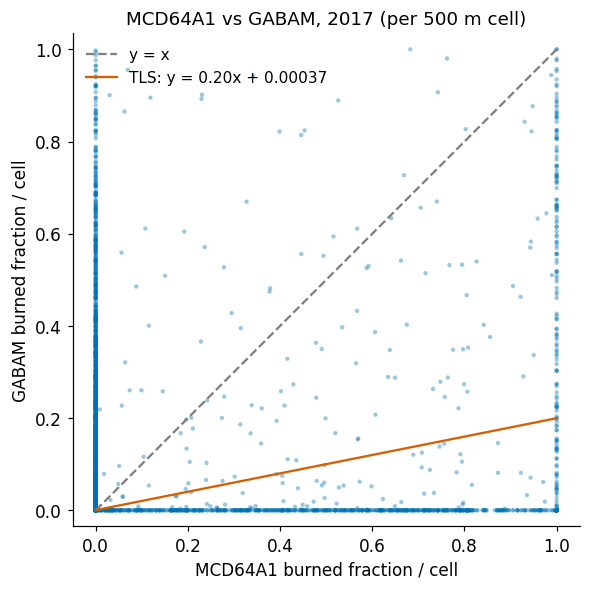

,MCD64A1,GABAM,FireCCI51,FireCCIS311
MCD64A1,1.00,14.94,1.57,-4.21
GABAM,0.07,1.00,0.41,2.17
FireCCI51,0.64,2.42,1.00,1.31
FireCCIS311,-0.24,0.46,0.76,1.00


,MCD64A1,GABAM,FireCCI51,FireCCIS311
MCD64A1,0.0,453.2,137.7,480.5
GABAM,453.2,0.0,417.2,349.2
FireCCI51,137.7,417.2,0.0,465.5
FireCCIS311,480.5,349.2,465.5,0.0


In [ ]:
# scatter of two products' per-cell burned fraction in one year, with TLS + y=x
x, y = product_pair_scatter("MCD64A1", "GABAM", 2017, aoi)
print("n scatter points (cells):", x.size)
if x.size:
    print("TLS slope, intercept:", total_least_squares(x, y), "| RMSE:", round(rmse(x, y), 4))
    plot_product_scatter(
        x, y,
        xlabel="MCD64A1 burned fraction / cell",
        ylabel="GABAM burned fraction / cell",
        title="MCD64A1 vs GABAM, 2017 (per 500 m cell)",
    )
    plt.show()

# TLS-slope and RMSE matrices on per-period totals (burned-area products, km^2)
tls = agreement_matrix(products_ba, years, aoi, method="tls_slope", pooling="years")
err = agreement_matrix(products_ba, years, aoi, method="rmse",      pooling="years")
display(tls.round(2)); display(err.round(1))

## 6. Overlay map for a chosen year

`stack_on_common_grid` aligns every product for the year; `plot_overlay_map` shows where a pair agree
(1 = A only, 2 = B only, 3 = both).

products present in 2017 stack: ['MCD64A1', 'GABAM', 'FireCCI51']


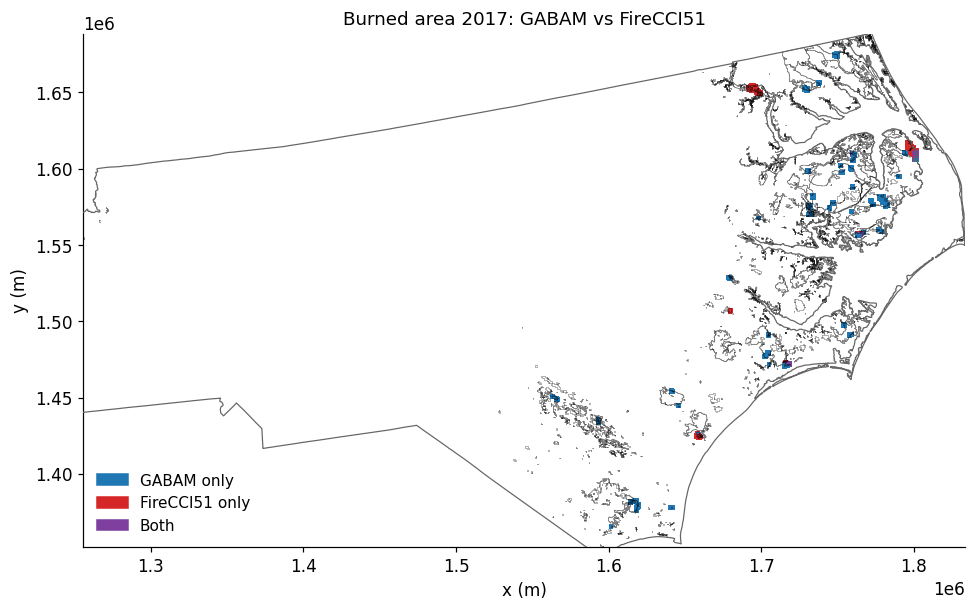

In [ ]:
year = 2017
stack = stack_on_common_grid(products_ba, year, aoi, binary=True)
pair=("GABAM", "FireCCI51")
print(f"products present in {year} stack:", list(stack))
if {pair[0], pair[1]} <= set(stack):
    fig, ax = plt.subplots(figsize=(9, 6))
    plot_overlay_map(stack, aoi, year, pair=pair, ax=ax)
    
    # plot the nc overlay too if it exists
    if aoi_nc is not None:
        crs = stack[pair[0]].rio.crs           # EPSG:5070, the analysis grid CRS
        xlim, ylim = ax.get_xlim(), ax.get_ylim()   # peat-extent view set by plot_overlay_map
        aoi_nc.to_crs(crs).boundary.plot(ax=ax, color="0.4", linewidth=0.8, zorder=5)
        ax.set_xlim(xlim); ax.set_ylim(ylim)   # restore it (geopandas autoscaled to NC)

    plt.savefig(f'../outputs/figures/fire/{pair[0]}_vs_{pair[1]}_{aoi_name}_extent_burned_area_{year}.png')
    plt.show()

## 6b. Multi-product consensus map (all burned-area products at once)

`plot_overlay_map` compares a *pair*; `plot_consensus_map` generalises it to **all** products. Every
product is on the same EPSG:5070 common grid (via `stack_on_common_grid`), and each burned cell is
coloured by **how many** products map a burn there (1 = a single product, N = unanimous). Pass
`month=` for a single month. Bright cells are the agreement core; dim fringe cells are mapped by only
one product.

products present in 2011 stack: ['MCD64A1', 'GABAM', 'FireCCI51']


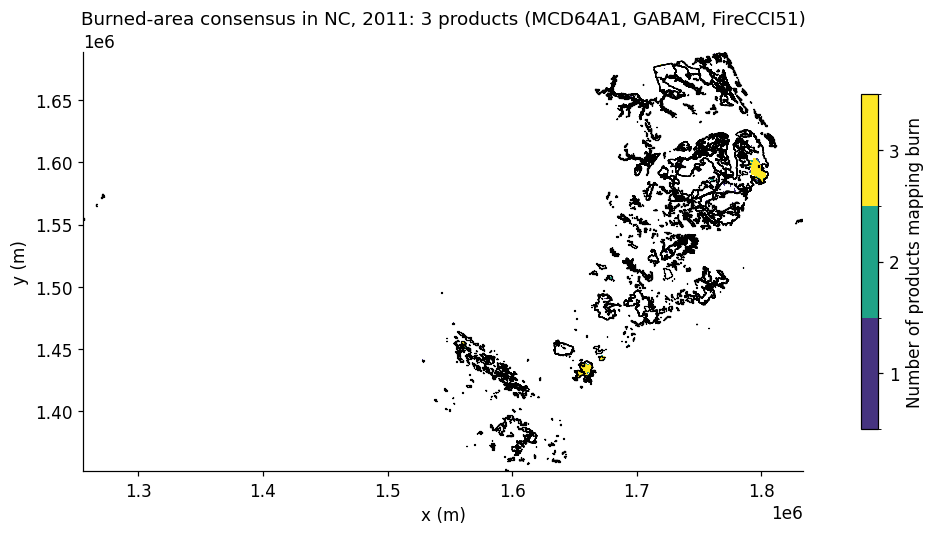

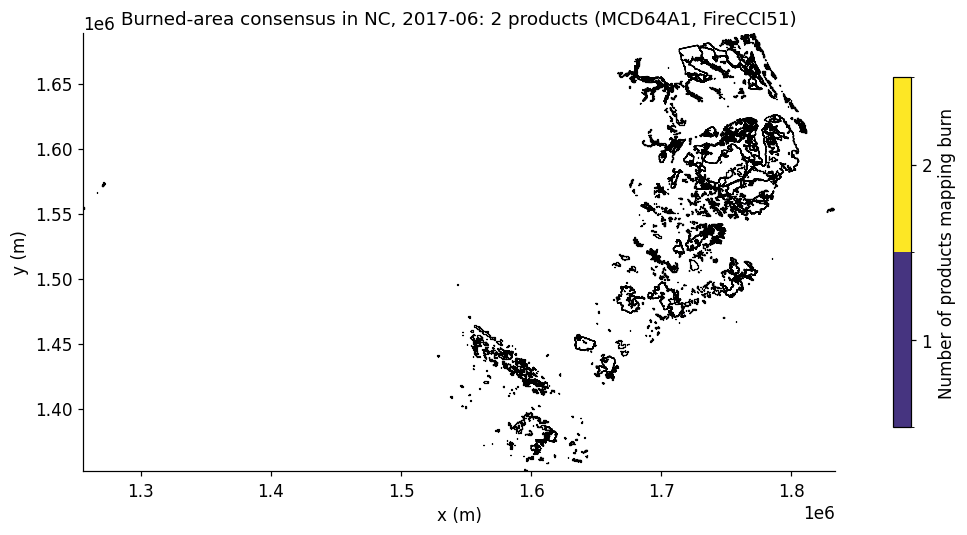

In [ ]:
# all burned-area products that have data for the year, on the NC common grid
stack_2011 = stack_on_common_grid(products_ba, 2011, aoi, binary=True)
print("products present in 2011 stack:", list(stack_2011))
fig = plot_consensus_map(stack_2011, aoi, 2011)
plt.show()

# single month works too: pass month= to the stack, then to the plot
stack_2017_06 = stack_on_common_grid(products_ba, 2017, aoi, binary=True, month=6)
if stack_2017_06:
    plot_consensus_map(stack_2017_06, aoi, 2017, month=6); plt.show()

### individual severity product maps for 2017

In [ ]:
year = 2016

sev_products = list_products('severity')
for prod in sev_products:
    stack = stack_on_common_grid([prod], year, aoi, binary=False)
    if prod not in stack:                      # graceful skip if not downloaded
        print(f"{prod}: no data, skipping"); continue
    sev = stack[prod]
    print(prod, "max:", float(sev.max()), "nonzero cells:", int((sev > 0).sum()))

    # severity
    fig = plot_raster_map(sev, aoi, title=f"{prod} severity {year}", aoi_context=aoi_nc)
    plt.savefig(f'../outputs/figures/fire/{prod}_{year}_{aoi_name}_extent_map.png', dpi=150, bbox_inches='tight')
    plt.close(fig)

SE_FireMap max: 2.0739989280700684 nonzero cells: 47
MOSEV max: 975.8417358398438 nonzero cells: 166
MTBS max: 3.0 nonzero cells: 187


occurrence map for specific year

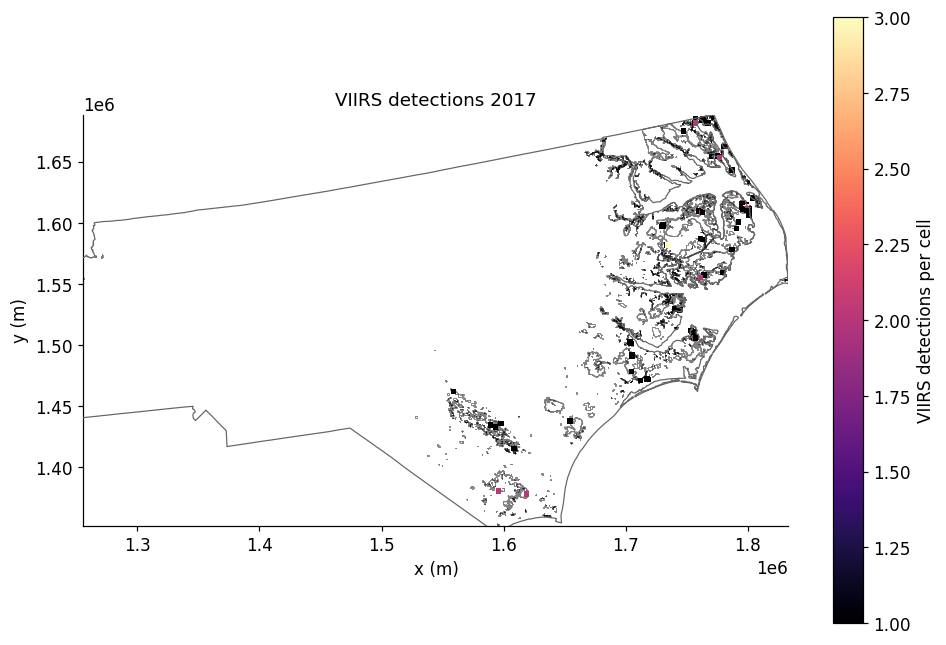

In [ ]:
year = 2017

counts = stack_on_common_grid(["VIIRS"], year, aoi, binary=False)["VIIRS"]  # detections / 500 m cell

fig = plot_raster_map(counts, aoi, title=f"VIIRS detections {year}",
                      label="VIIRS detections per cell", aoi_context=aoi_nc)

plt.savefig(f'../outputs/figures/fire/viirs_{year}_{aoi_name}_extent_map.png')

## 7. Monthly mode

One flag: `temporal_unit="month"`. Annual-only products (GABAM, USGS_BA, ...) are dropped; the monthly
products + VIIRS remain. The series index becomes month-start Timestamps.

,MCD64A1,MCD64A1_pct_aoi,FireCCI51,FireCCI51_pct_aoi
period,,,,
2017-01-01,0.00,0.000000,0.00,0.000000
2017-02-01,0.75,0.013799,0.00,0.000000
2017-03-01,19.50,0.358773,15.75,0.289778
2017-04-01,0.00,0.000000,27.50,0.505962
2017-05-01,0.00,0.000000,0.00,0.000000
2017-06-01,4.25,0.078194,7.50,0.137990
2017-07-01,0.50,0.009199,5.25,0.096593
2017-08-01,0.00,0.000000,0.00,0.000000
2017-09-01,0.00,0.000000,0.50,0.009199


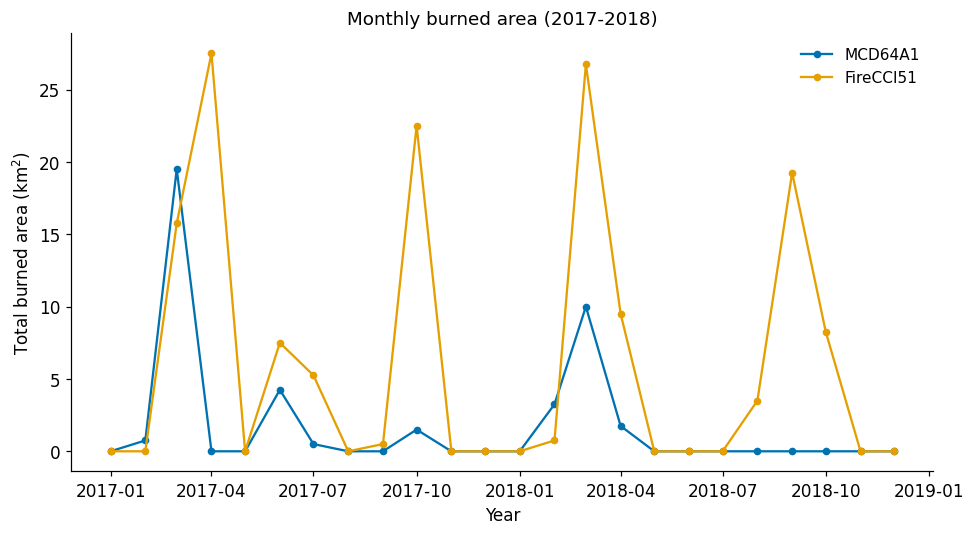

In [ ]:
area_monthly = annual_burned_area_series(
    ["MCD64A1", "FireCCI51", "FireCCIS311"], range(2017, 2019),
    aoi, mode="common_grid", temporal_unit="month",
)
display(area_monthly.head(14))
plot_annual_series(area_monthly, title="Monthly burned area (2017-2018)"); plt.show()

## 7b. Temporal heat map (Humber-style)

`period_totals_series` gives, per month, burned-area km² for each product and the VIIRS active-fire
**detection count**. `plot_temporal_heatmap` lays this out as products × time, with VIIRS as the bottom
reference row. By default each row is normalised to its own max so the *timing* is comparable across
products despite the different units — bright cells lining up vertically mean a product's burn
detections coincide with active fire.

,MCD64A1,FireCCI51,GABAM,VIIRS,FireCCIS311
year,,,,,
2012,116.00,145.50,102.75,384,NaN
2013,11.00,20.75,206.00,138,NaN
2014,6.25,23.50,93.75,83,NaN
2015,41.25,47.25,81.00,178,NaN
2016,77.00,121.25,126.75,201,NaN
2017,26.00,69.25,86.00,184,NaN
2018,15.00,57.25,83.25,111,NaN
2019,8.25,11.50,79.50,79,38.50
2020,39.75,18.50,91.25,134,44.25


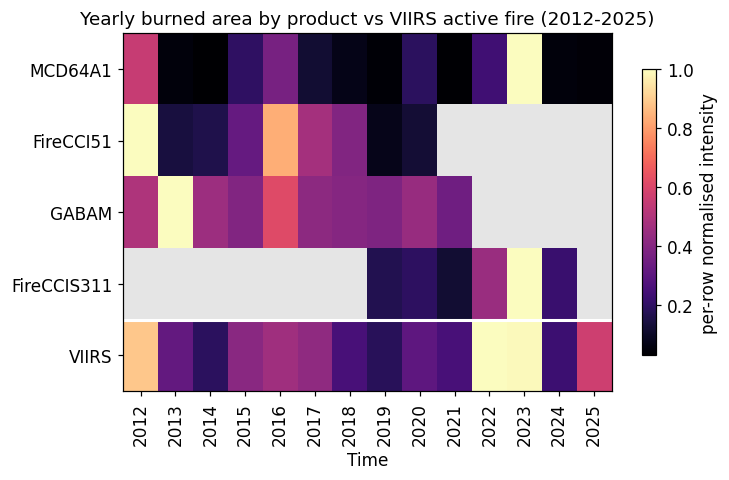

In [ ]:
products = ["MCD64A1", "FireCCI51", "FireCCIS311", "GABAM", "VIIRS"]
years = range(2012, 2026)          
temporal_unit = "year" # year or month
title = f"Yearly burned area by product vs VIIRS active fire ({years[0]}-{years[-1]})"

totals = period_totals_series(products, years, aoi, temporal_unit)
display(totals.head(14))

fig = plot_temporal_heatmap(totals, normalize="row", title=title)

products_save_str = "_".join(products)
fig.savefig(
    f"../outputs/figures/fire/{products_save_str}_{years[0]}_to_{years[-1]}_temporal_heatmap_by_{temporal_unit}_{aoi_name}_extent.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

## 8. One-call full comparison (writes CSVs)

`compare_fire_products` runs the whole thing and (with `out_dir`) saves every table. Point `aoi` at a
peatland shapefile later and rerun — nothing else changes.

In [ ]:
res = compare_fire_products(
    data_path("processed", "boundaries", "nc_boundary.gpkg"),
    products=["MCD64A1", "GABAM", "FireCCI51", "USGS_BA", "VIIRS"],
    years=range(2001, 2022),
    agreement_methods=("jaccard", "kappa"),
    overlay_years=[2017],
    out_dir=data_path("processed", "fire", "comparison", "nc"),
)
print("result keys:", list(res))
display(res["area_common_grid"].head())
display(res["agreement_jaccard"].round(2))

In [ ]:
# monthly full run (annual-only products auto-dropped)
res_m = compare_fire_products(
    data_path("processed", "boundaries", "nc_boundary.gpkg"),
    years=range(2017, 2019),
    temporal_unit="month",
    overlay_years=[(2017, 6)],
    out_dir=data_path("processed", "fire", "comparison", "nc_monthly"),
)
print("monthly result keys:", list(res_m))
display(res_m["area_common_grid"].head(14))